In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q monai segmentation-models-pytorch albumentations

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.6 MB/s eta 0:00:00


In [ ]:
!pip install torchinfo

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import cv2
import random
import copy
import matplotlib.pyplot as plt
from tqdm import tqdm

from monai.losses import DiceFocalLoss
from monai.metrics import DiceMetric, MeanIoU
from monai.transforms import (
    Compose, RandRotated, RandFlipd, RandZoomd, RandAffined,
    RandGaussianNoised, RandAdjustContrastd, ToTensord
)
import segmentation_models_pytorch as smp

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
CT_DIR = '/content/drive/MyDrive/Minor-Project under DevraniMam/Faderated_Learning_Based_Lung_Nodule_Detection/LUNA16_segmentation_data/ct'
MASK_DIR = '/content/drive/MyDrive/Minor-Project under DevraniMam/Faderated_Learning_Based_Lung_Nodule_Detection/LUNA16_segmentation_data/mask'

ct_files = sorted([f for f in os.listdir(CT_DIR) if f.endswith('.png')])
mask_files = sorted([f for f in os.listdir(MASK_DIR) if f.endswith('.png')])

assert len(ct_files) == len(mask_files), "CT and mask counts mismatch!"
print(f"Total images: {len(ct_files)}")

ct_paths = [os.path.join(CT_DIR, f) for f in ct_files]
mask_paths = [os.path.join(MASK_DIR, f) for f in mask_files]

Total images: 523


In [ ]:
class LungNoduleDataset(Dataset):
    def __init__(self, ct_paths, mask_paths, transform=None):
        self.ct_paths = ct_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.ct_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.ct_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (256, 256))
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

        img = img.astype(np.float32) / 255.0
        mask = (mask > 127).astype(np.float32)

        img = np.expand_dims(img, axis=0)
        mask = np.expand_dims(mask, axis=0)

        data = {'image': img, 'mask': mask}
        if self.transform:
            data = self.transform(data)
        return data['image'], data['mask']

train_transforms = Compose([
    RandRotated(keys=['image','mask'], range_x=0.3, prob=0.5, mode=['bilinear','nearest']),
    RandFlipd(keys=['image','mask'], spatial_axis=0, prob=0.5),
    RandFlipd(keys=['image','mask'], spatial_axis=1, prob=0.5),
    RandZoomd(keys=['image','mask'], min_zoom=0.8, max_zoom=1.2, prob=0.5, mode=['bilinear','nearest']),
    RandAffined(keys=['image','mask'], rotate_range=0.2, translate_range=0.1, scale_range=0.1, prob=0.5, mode=['bilinear','nearest']),
    RandGaussianNoised(keys=['image'], std=0.01, prob=0.3),
    RandAdjustContrastd(keys=['image'], gamma=(0.8,1.2), prob=0.3),
    ToTensord(keys=['image','mask'], dtype=torch.float32),
])

val_transforms = Compose([
    ToTensord(keys=['image','mask'], dtype=torch.float32),
])

In [ ]:
def split_clients(ct_paths, mask_paths, num_clients=5, val_ratio=0.15, test_ratio=0.15):
    indices = np.arange(len(ct_paths))
    np.random.shuffle(indices)
    client_indices = np.array_split(indices, num_clients)

    clients = []
    for client_idx in client_indices:
        train_idx, temp_idx = train_test_split(client_idx, test_size=(val_ratio+test_ratio), random_state=42)
        val_idx, test_idx = train_test_split(temp_idx, test_size=test_ratio/(val_ratio+test_ratio), random_state=42)
        clients.append({
            'train': train_idx.tolist(),
            'val': val_idx.tolist(),
            'test': test_idx.tolist()
        })
    return clients

clients = split_clients(ct_paths, mask_paths, num_clients=5)
print("Client data sizes:")
for i, c in enumerate(clients):
    print(f"Client {i}: train={len(c['train'])}, val={len(c['val'])}, test={len(c['test'])}")

Client data sizes:
Client 0: train=73, val=16, test=16
Client 1: train=73, val=16, test=16
Client 2: train=73, val=16, test=16
Client 3: train=72, val=16, test=16
Client 4: train=72, val=16, test=16


In [ ]:
batch_size = 8
num_workers = 2

client_dataloaders = []
for client in clients:
    train_ds = LungNoduleDataset([ct_paths[i] for i in client['train']],
                                 [mask_paths[i] for i in client['train']],
                                 transform=train_transforms)
    val_ds = LungNoduleDataset([ct_paths[i] for i in client['val']],
                               [mask_paths[i] for i in client['val']],
                               transform=val_transforms)
    test_ds = LungNoduleDataset([ct_paths[i] for i in client['test']],
                                [mask_paths[i] for i in client['test']],
                                transform=val_transforms)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    client_dataloaders.append({
        'train': train_loader,
        'val': val_loader,
        'test': test_loader
    })

In [ ]:
def build_model():
    model = smp.UnetPlusPlus(
        encoder_name="efficientnet-b3",
        encoder_weights="imagenet",
        in_channels=1,
        classes=1,
    )
    return model


model = build_model().to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

from torchinfo import summary
summary(model, input_size=(1, 1, 256, 256))

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 49.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Model parameters: 13.62M


Layer (type:depth-idx)                                  Output Shape              Param #
UnetPlusPlus                                            [1, 1, 256, 256]          --
├─EfficientNetEncoder: 1-1                              [1, 1, 256, 256]          592,896
│    └─Conv2dStaticSamePadding: 2-1                     [1, 40, 128, 128]         360
│    │    └─ZeroPad2d: 3-1                              [1, 1, 257, 257]          --
│    └─BatchNorm2d: 2-2                                 [1, 40, 128, 128]         80
│    └─SiLU: 2-3                                        [1, 40, 128, 128]         --
│    └─ModuleList: 2-4                                  --                        --
│    │    └─MBConvBlock: 3-2                            [1, 24, 128, 128]         2,298
│    │    └─MBConvBlock: 3-3                            [1, 24, 128, 128]         1,206
│    │    └─MBConvBlock: 3-4                            [1, 32, 64, 64]           11,878
│    │    └─MBConvBlock: 3-5                

In [ ]:
loss_fn = DiceFocalLoss(sigmoid=True, squared_pred=True, reduction='mean')
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

def compute_dice(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    return (2. * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)

def compute_iou(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

In [ ]:
def client_update(global_weights, train_loader, local_epochs=2, lr=1e-4, verbose=True):
    model = build_model().to(device)
    model.load_state_dict(global_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

    model.train()
    epoch_losses = []
    epoch_dices = []

    for epoch in range(local_epochs):
        running_loss = 0.0
        running_dice = 0.0
        num_batches = 0

        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            loss = loss_fn(logits, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            dice = compute_dice(logits.detach(), masks)
            running_loss += loss.item()
            running_dice += dice.item()
            num_batches += 1

        avg_loss = running_loss / num_batches
        avg_dice = running_dice / num_batches
        epoch_losses.append(avg_loss)
        epoch_dices.append(avg_dice)

        if verbose:
            print(f"    Local Epoch {epoch+1}/{local_epochs} - Loss: {avg_loss:.4f}, Dice: {avg_dice:.4f}")

    return model.state_dict(), len(train_loader.dataset), epoch_losses, epoch_dices

def aggregate_weights(client_weights, total_samples):
    new_weights = {}
    for key in client_weights[0][0].keys():
        weighted_sum = torch.zeros_like(client_weights[0][0][key])
        for w, n in client_weights:
            weighted_sum += w[key] * n
        new_weights[key] = weighted_sum / total_samples
    return new_weights

def evaluate(weights, dataloader):
    model = build_model().to(device)
    model.load_state_dict(weights)
    model.eval()
    dice_scores = []
    iou_scores = []
    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            dice = compute_dice(logits, masks)
            iou = compute_iou(logits, masks)
            dice_scores.append(dice.item())
            iou_scores.append(iou.item())
    return np.mean(dice_scores), np.mean(iou_scores)

In [ ]:
def compute_dice_from_probs(probs, target, threshold=0.5):
    preds = (probs > threshold).float()
    intersection = (preds * target).sum()
    return (2. * intersection + 1e-6) / (preds.sum() + target.sum() + 1e-6)

def compute_iou_from_probs(probs, target, threshold=0.5):
    preds = (probs > threshold).float()
    intersection = (preds * target).sum()
    union = preds.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

def postprocess_mask_light(mask, min_area=2, fill_holes=True):
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()
    mask = mask.astype(np.uint8)
    num_labels, labels = cv2.connectedComponents(mask)
    cleaned = np.zeros_like(mask)
    for lab in range(1, num_labels):
        component = (labels == lab).astype(np.uint8)
        if np.sum(component) >= min_area:
            cleaned = np.logical_or(cleaned, component)
    cleaned = cleaned.astype(np.uint8)
    if fill_holes:
        contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            cv2.drawContours(cleaned, [cnt], 0, 1, thickness=cv2.FILLED)
    return cleaned

def find_best_threshold(weights, val_loader):
    model = build_model().to(device)
    model.load_state_dict(weights)
    model.eval()
    best_dice = 0.0
    best_thresh = 0.5
    thresholds = np.arange(0.3, 0.7, 0.02)
    with torch.no_grad():
        for thresh in thresholds:
            dice_scores = []
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                logits = model(imgs)
                probs = torch.sigmoid(logits)
                dice = compute_dice_from_probs(probs, masks, threshold=thresh)
                dice_scores.append(dice.item())
            avg_dice = np.mean(dice_scores)
            if avg_dice > best_dice:
                best_dice = avg_dice
                best_thresh = thresh
    return best_thresh

def evaluate_with_optimizations(weights, dataloader, threshold=0.5, apply_postprocess=True):
    model = build_model().to(device)
    model.load_state_dict(weights)
    model.eval()
    dice_scores = []
    iou_scores = []
    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float().cpu().numpy()
            if apply_postprocess:
                preds_pp = np.zeros_like(preds)
                for i in range(preds.shape[0]):
                    preds_pp[i,0] = postprocess_mask_light(preds[i,0], min_area=2, fill_holes=True)
                preds = torch.tensor(preds_pp, device=device).float()
            else:
                preds = torch.tensor(preds, device=device).float()
            dice = compute_dice_from_pred(preds, masks)
            iou = compute_iou_from_pred(preds, masks)
            dice_scores.append(dice.item())
            iou_scores.append(iou.item())
    return np.mean(dice_scores), np.mean(iou_scores)

def compute_dice_from_pred(preds, target):
    intersection = (preds * target).sum()
    return (2. * intersection + 1e-6) / (preds.sum() + target.sum() + 1e-6)

def compute_iou_from_pred(preds, target):
    intersection = (preds * target).sum()
    union = preds.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

# Additional metric functions for comparison
def compute_precision_recall_iou(preds, targets, smooth=1e-6):
    preds_flat = preds.view(-1)
    targets_flat = targets.view(-1)
    tp = (preds_flat * targets_flat).sum()
    fp = (preds_flat * (1 - targets_flat)).sum()
    fn = ((1 - preds_flat) * targets_flat).sum()
    tn = ((1 - preds_flat) * (1 - targets_flat)).sum()
    precision = (tp + smooth) / (tp + fp + smooth)
    recall = (tp + smooth) / (tp + fn + smooth)
    iou_fg = (tp + smooth) / (tp + fp + fn + smooth)
    iou_bg = (tn + smooth) / (tn + fp + fn + smooth)
    miou = (iou_fg + iou_bg) / 2.0
    return precision.item(), recall.item(), iou_fg.item(), miou.item()

def evaluate_full_metrics(weights, dataloader, threshold=0.5, apply_postprocess=True):
    model = build_model().to(device)
    model.load_state_dict(weights)
    model.eval()
    precisions, recalls, ious_fg, mious = [], [], [], []
    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float().cpu().numpy()
            if apply_postprocess:
                preds_pp = np.zeros_like(preds)
                for i in range(preds.shape[0]):
                    preds_pp[i,0] = postprocess_mask_light(preds[i,0], min_area=2, fill_holes=True)
                preds = torch.tensor(preds_pp, device=device).float()
            else:
                preds = torch.tensor(preds, device=device).float()
            precision, recall, iou_fg, miou = compute_precision_recall_iou(preds, masks)
            precisions.append(precision)
            recalls.append(recall)
            ious_fg.append(iou_fg)
            mious.append(miou)
    return np.mean(precisions), np.mean(recalls), np.mean(ious_fg), np.mean(mious)

In [ ]:
global_weights = build_model().state_dict()
global_weights = {k: v.to(device) for k, v in global_weights.items()}

num_rounds = 50
local_epochs = 2
local_lr = 1e-4

results = {'round': [], 'avg_val_dice': [], 'avg_test_dice': [], 'avg_test_iou': []}

for round in range(num_rounds):
    print(f"--- Federated Round {round+1}/{num_rounds} ---")
    client_weights = []
    total_samples = 0

    for i, client in enumerate(client_dataloaders):
        print(f"  Client {i} training...")
        w, n, _, _ = client_update(global_weights, client['train'],
                                   local_epochs=local_epochs, lr=local_lr, verbose=True)
        client_weights.append((w, n))
        total_samples += n

    global_weights = aggregate_weights(client_weights, total_samples)

    if (round+1) % 5 == 0 or round == num_rounds-1:
        val_dices = []
        test_dices = []
        test_ious = []
        for i, client in enumerate(client_dataloaders):
            val_dice, _ = evaluate(global_weights, client['val'])
            test_dice, test_iou = evaluate(global_weights, client['test'])
            val_dices.append(val_dice)
            test_dices.append(test_dice)
            test_ious.append(test_iou)
        avg_val_dice = np.mean(val_dices)
        avg_test_dice = np.mean(test_dices)
        avg_test_iou = np.mean(test_ious)
        results['round'].append(round+1)
        results['avg_val_dice'].append(avg_val_dice)
        results['avg_test_dice'].append(avg_test_dice)
        results['avg_test_iou'].append(avg_test_iou)
        print(f"  Round {round+1}: Avg Val Dice={avg_val_dice:.4f}, Avg Test Dice={avg_test_dice:.4f}, Avg Test IoU={avg_test_iou:.4f}")

global_weights_fedavg = global_weights

--- Federated Round 1/50 ---
  Client 0 training...
    Local Epoch 1/2 - Loss: 1.1370, Dice: 0.0014
    Local Epoch 2/2 - Loss: 1.0905, Dice: 0.0035
  Client 1 training...
    Local Epoch 1/2 - Loss: 1.1396, Dice: 0.0011
    Local Epoch 2/2 - Loss: 1.0896, Dice: 0.0027
  Client 2 training...
    Local Epoch 1/2 - Loss: 1.1379, Dice: 0.0013
    Local Epoch 2/2 - Loss: 1.0923, Dice: 0.0029
  Client 3 training...
    Local Epoch 1/2 - Loss: 1.1399, Dice: 0.0015
    Local Epoch 2/2 - Loss: 1.0980, Dice: 0.0023
  Client 4 training...
    Local Epoch 1/2 - Loss: 1.1414, Dice: 0.0013
    Local Epoch 2/2 - Loss: 1.0944, Dice: 0.0034
--- Federated Round 2/50 ---
  Client 0 training...
    Local Epoch 1/2 - Loss: 1.0663, Dice: 0.0056
    Local Epoch 2/2 - Loss: 1.0480, Dice: 0.0099
  Client 1 training...
    Local Epoch 1/2 - Loss: 1.0651, Dice: 0.0049
    Local Epoch 2/2 - Loss: 1.0486, Dice: 0.0089
  Client 2 training...
    Local Epoch 1/2 - Loss: 1.0665, Dice: 0.0048
    Local Epoch 2/2 - L

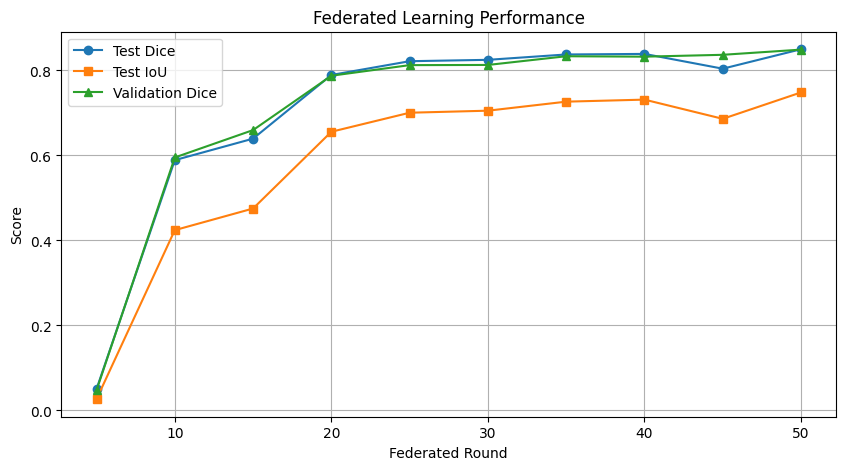

Model saved!


In [ ]:
plt.figure(figsize=(10,5))
plt.plot(results['round'], results['avg_test_dice'], label='Test Dice', marker='o')
plt.plot(results['round'], results['avg_test_iou'], label='Test IoU', marker='s')
plt.plot(results['round'], results['avg_val_dice'], label='Validation Dice', marker='^')
plt.xlabel('Federated Round')
plt.ylabel('Score')
plt.legend()
plt.title('Federated Learning Performance')
plt.grid(True)
plt.show()

torch.save(global_weights, '/content/drive/MyDrive/federated_lung_nodule_unetpp_effb3(2).pth')
print("Model saved!")

In [ ]:
def client_update(global_weights, train_loader, local_epochs=2, lr=1e-4, verbose=True):
    model = build_model().to(device)
    model.load_state_dict(global_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

    model.train()
    epoch_losses = []
    epoch_dices = []

    for epoch in range(local_epochs):
        running_loss = 0.0
        running_dice = 0.0
        num_batches = 0

        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            loss = loss_fn(logits, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            dice = compute_dice(logits.detach(), masks)
            running_loss += loss.item()
            running_dice += dice.item()
            num_batches += 1

        avg_loss = running_loss / num_batches
        avg_dice = running_dice / num_batches
        epoch_losses.append(avg_loss)
        epoch_dices.append(avg_dice)

        if verbose:
            print(f"    Local Epoch {epoch+1}/{local_epochs} - Loss: {avg_loss:.4f}, Dice: {avg_dice:.4f}")

    return model.state_dict(), len(train_loader.dataset), epoch_losses, epoch_dices

def aggregate_weights(client_weights, total_samples):
    new_weights = {}
    for key in client_weights[0][0].keys():
        weighted_sum = torch.zeros_like(client_weights[0][0][key])
        for w, n in client_weights:
            weighted_sum += w[key] * n
        new_weights[key] = weighted_sum / total_samples
    return new_weights

# ---------- FedProx Client Update ----------
def client_update_fedprox(global_weights, train_loader, local_epochs=2, lr=1e-4, mu=0.01, verbose=False):
    model = build_model().to(device)
    model.load_state_dict(global_weights)
    global_params = [p.detach().clone() for p in model.parameters()]
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    model.train()
    for epoch in range(local_epochs):
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            loss = loss_fn(logits, masks)
            prox_loss = 0.0
            for param, g_param in zip(model.parameters(), global_params):
                prox_loss += ((param - g_param) ** 2).sum()
            loss += (mu / 2) * prox_loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model.state_dict(), len(train_loader.dataset)

# ---------- FedProx++ Client Update (decaying mu + gradient clipping) ----------
def client_update_fedprox_plus(global_weights, train_loader, local_epochs=2, lr=1e-4, mu=0.05, decay=0.9, round_num=0, verbose=False):
    mu_eff = mu * (decay ** round_num)
    model = build_model().to(device)
    model.load_state_dict(global_weights)
    global_params = [p.detach().clone() for p in model.parameters()]
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    model.train()
    for epoch in range(local_epochs):
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            loss = loss_fn(logits, masks)
            prox_loss = 0.0
            for param, g_param in zip(model.parameters(), global_params):
                prox_loss += ((param - g_param) ** 2).sum()
            loss += (mu_eff / 2) * prox_loss
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
    return model.state_dict(), len(train_loader.dataset)

# ---------- FedOpt (FedAdam) Server Aggregation ----------
def aggregate_fedopt(global_weights, client_weights, total_samples, server_optimizer_state, server_lr=1e-3):
    # client_weights: list of (weights, num_samples)
    avg_delta = {}
    for key in client_weights[0][0].keys():
        # Ensure weighted_sum is on the correct device and is always float
        weighted_sum = torch.zeros_like(client_weights[0][0][key], dtype=torch.float, device=device)
        for w, n in client_weights:
            # Explicitly move global_weights[key] to the correct device for subtraction
            delta = w[key] - global_weights[key].to(device)
            weighted_sum += delta * float(n) # Cast n to float for multiplication
        avg_delta[key] = weighted_sum / total_samples

    new_weights = {}
    if server_optimizer_state is None:
        server_optimizer_state = {'m': {}, 'v': {}, 't': 0}
    server_optimizer_state['t'] += 1
    t = server_optimizer_state['t']
    beta1, beta2, eps = 0.9, 0.999, 1e-8
    for key, delta in avg_delta.items():
        if key not in server_optimizer_state['m']:
            # Ensure optimizer state tensors are on the correct device and are float
            server_optimizer_state['m'][key] = torch.zeros_like(delta, dtype=torch.float, device=device)
            server_optimizer_state['v'][key] = torch.zeros_like(delta, dtype=torch.float, device=device)
        m = beta1 * server_optimizer_state['m'][key] + (1 - beta1) * delta
        v = beta2 * server_optimizer_state['v'][key] + (1 - beta2) * (delta ** 2)
        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)
        update = m_hat / (torch.sqrt(v_hat) + eps)
        # Explicitly move global_weights[key] to the correct device for addition
        new_weights[key] = global_weights[key].to(device) + server_lr * update
        server_optimizer_state['m'][key] = m
        server_optimizer_state['v'][key] = v
    return new_weights, server_optimizer_state

def train_federated_algorithm(algorithm, num_rounds=50, local_epochs=2, local_lr=1e-4,
                              mu=0.01, server_lr=1e-3, verbose=False):
    # Initialize global weights on CPU, then move to device
    global_weights = build_model().state_dict()
    global_weights = {k: v.to(device) for k, v in global_weights.items()}

    results = {'round': [], 'val_dice': [], 'test_dice': [], 'test_iou': []}
    server_optimizer_state = None if algorithm != 'fedopt' else {'m': {}, 'v': {}, 't': 0}

    for round_num in range(num_rounds):
        if verbose:
            print(f"--- {algorithm.upper()} Round {round_num+1}/{num_rounds} ---")
        client_weights = []
        total_samples = 0

        for i, client in enumerate(client_dataloaders):
            if algorithm == 'fedavg':
                w, n, _, _ = client_update(global_weights, client['train'],
                                           local_epochs=local_epochs, lr=local_lr, verbose=False)
            elif algorithm == 'fedprox':
                w, n = client_update_fedprox(global_weights, client['train'],
                                             local_epochs=local_epochs, lr=local_lr,
                                             mu=mu, verbose=False)
            elif algorithm == 'fedprox++':
                w, n = client_update_fedprox_plus(global_weights, client['train'],
                                                  local_epochs=local_epochs, lr=local_lr,
                                                  mu=mu, decay=0.9, round_num=round_num,
                                                  verbose=False)
            elif algorithm == 'fedopt':
                w, n, _, _ = client_update(global_weights, client['train'],
                                           local_epochs=local_epochs, lr=local_lr, verbose=False)
            else:
                raise ValueError(f"Unknown algorithm: {algorithm}")

            client_weights.append((w, n))
            total_samples += n

        # Corrected aggregation logic
        if algorithm == 'fedopt':
            global_weights, server_optimizer_state = aggregate_fedopt(
                global_weights, client_weights, total_samples,
                server_optimizer_state, server_lr=server_lr
            )
        else: # For fedavg, fedprox, fedprox++
            global_weights = aggregate_weights(client_weights, total_samples)

        if (round_num+1) % 5 == 0 or round_num == num_rounds-1:
            val_dice, _ = evaluate(global_weights, client_dataloaders[0]['val'])
            test_dices, test_ious = [], []
            for cl in client_dataloaders:
                d, iou = evaluate(global_weights, cl['test'])
                test_dices.append(d)
                test_ious.append(iou)
            results['round'].append(round_num+1)
            results['val_dice'].append(val_dice)
            results['test_dice'].append(np.mean(test_dices))
            results['test_iou'].append(np.mean(test_ious))
            if verbose:
                print(f"  Round {round_num+1}: Val Dice={val_dice:.4f}, Avg Test Dice={np.mean(test_dices):.4f}, Avg Test IoU={np.mean(test_ious):.4f}")

    return global_weights, results

In [ ]:
# Set parameters (reduce num_rounds if time is a concern)
comparison_rounds = 50   # same as baseline for fair comparison
local_epochs = 2
local_lr = 1e-4
mu = 0.01
server_lr = 1e-3

algorithms_to_train = ['fedprox', 'fedprox++', 'fedopt']
comparison_weights = {}
comparison_results = {}

# FedAvg already trained and stored in global_weights_fedavg
comparison_weights['fedavg'] = global_weights_fedavg
# We'll also recompute results for FedAvg? It was already logged; we can skip.
# For completeness, we can evaluate FedAvg final metrics later.

for alg in algorithms_to_train:
    print(f"\n========== Training {alg.upper()} ==========")
    w, res = train_federated_algorithm(
        algorithm=alg,
        num_rounds=comparison_rounds,
        local_epochs=local_epochs,
        local_lr=local_lr,
        mu=mu,
        server_lr=server_lr,
        verbose=True
    )
    comparison_weights[alg] = w
    comparison_results[alg] = res
    # Save model
    torch.save(w, f'/content/drive/MyDrive/federated_lung_nodule_{alg}.pth')
    print(f"{alg.upper()} training complete.\n")

print("All algorithms trained.")


========== Training FEDPROX ==========
--- FEDPROX Round 1/50 ---
--- FEDPROX Round 2/50 ---
--- FEDPROX Round 3/50 ---
--- FEDPROX Round 4/50 ---
--- FEDPROX Round 5/50 ---
  Round 5: Val Dice=0.0175, Avg Test Dice=0.0356, Avg Test IoU=0.0183
--- FEDPROX Round 6/50 ---
--- FEDPROX Round 7/50 ---
--- FEDPROX Round 8/50 ---
--- FEDPROX Round 9/50 ---
--- FEDPROX Round 10/50 ---
  Round 10: Val Dice=0.3903, Avg Test Dice=0.3377, Avg Test IoU=0.2051
--- FEDPROX Round 11/50 ---
--- FEDPROX Round 12/50 ---
--- FEDPROX Round 13/50 ---
--- FEDPROX Round 14/50 ---
--- FEDPROX Round 15/50 ---
  Round 15: Val Dice=0.5361, Avg Test Dice=0.5132, Avg Test IoU=0.3491
--- FEDPROX Round 16/50 ---
--- FEDPROX Round 17/50 ---
--- FEDPROX Round 18/50 ---
--- FEDPROX Round 19/50 ---
--- FEDPROX Round 20/50 ---
  Round 20: Val Dice=0.7199, Avg Test Dice=0.6401, Avg Test IoU=0.4733
--- FEDPROX Round 21/50 ---
--- FEDPROX Round 22/50 ---
--- FEDPROX Round 23/50 ---
--- FEDPROX Round 24/50 ---
--- FEDPROX Ro

In [ ]:
def compute_optimized_metrics_for_algorithm(weights, algorithm_name):
    if algorithm_name == 'fedopt':
        return
    thresh = find_best_threshold(weights, client_dataloaders[0]['val'])
    print(f"{algorithm_name}: Best threshold (client 0 val) = {thresh:.2f}")
    client_metrics = []
    for i, client in enumerate(client_dataloaders):
        dice, iou = evaluate_with_optimizations(weights, client['test'],
                                                threshold=thresh, apply_postprocess=True)
        precision, recall, iou_fg, miou = evaluate_full_metrics(weights, client['test'],
                                                                threshold=thresh, apply_postprocess=True)
        client_metrics.append({
            'client': i,
            'dice': dice,
            'iou': iou,           # foreground IoU
            'precision': precision,
            'recall': recall,
            'miou': miou
        })
        print(f"  Client {i}: Dice={dice:.4f}, IoU={iou:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, mIoU={miou:.4f}")

    avg_dice = np.mean([m['dice'] for m in client_metrics])
    avg_iou = np.mean([m['iou'] for m in client_metrics])
    avg_precision = np.mean([m['precision'] for m in client_metrics])
    avg_recall = np.mean([m['recall'] for m in client_metrics])
    avg_miou = np.mean([m['miou'] for m in client_metrics])
    print(f"  Average: Dice={avg_dice:.4f}, IoU={avg_iou:.4f}, Precision={avg_precision:.4f}, Recall={avg_recall:.4f}, mIoU={avg_miou:.4f}\n")
    return {'threshold': thresh, 'client_metrics': client_metrics,
            'avg_dice': avg_dice, 'avg_iou': avg_iou,
            'avg_precision': avg_precision, 'avg_recall': avg_recall, 'avg_miou': avg_miou}

# Evaluate FedAvg baseline
print("===== Evaluating FedAvg (Baseline) =====")
comparison_metrics = {}
comparison_metrics['fedavg'] = compute_optimized_metrics_for_algorithm(global_weights_fedavg, 'FedAvg')

# Evaluate other algorithms
for alg in algorithms_to_train:
    print(f"===== Evaluating {alg.upper()} =====")
    comparison_metrics[alg] = compute_optimized_metrics_for_algorithm(comparison_weights[alg], alg.upper())

===== Evaluating FedAvg (Baseline) =====
FedAvg: Best threshold (client 0 val) = 0.34
  Client 0: Dice=0.8590, IoU=0.7541, Precision=0.9015, Recall=0.8211, mIoU=0.8769
  Client 1: Dice=0.8837, IoU=0.7917, Precision=0.8483, Recall=0.9230, mIoU=0.8957
  Client 2: Dice=0.9051, IoU=0.8280, Precision=0.8719, Recall=0.9412, mIoU=0.9139
  Client 3: Dice=0.7157, IoU=0.5731, Precision=0.7134, Recall=0.7600, mIoU=0.7863
  Client 4: Dice=0.8991, IoU=0.8171, Precision=0.9421, Recall=0.8624, mIoU=0.9085
  Average: Dice=0.8525, IoU=0.7528, Precision=0.8555, Recall=0.8616, mIoU=0.8763

===== Evaluating FEDPROX =====
FEDPROX: Best threshold (client 0 val) = 0.38
  Client 0: Dice=0.8357, IoU=0.7196, Precision=0.9137, Recall=0.7751, mIoU=0.8596
  Client 1: Dice=0.8975, IoU=0.8146, Precision=0.8767, Recall=0.9212, mIoU=0.9072
  Client 2: Dice=0.9022, IoU=0.8222, Precision=0.9116, Recall=0.8934, mIoU=0.9110
  Client 3: Dice=0.6997, IoU=0.5468, Precision=0.7327, Recall=0.7136, mIoU=0.7732
  Client 4: Dice=

In [ ]:
# Summary DataFrame
import pandas as pd
summary_data = []
for alg in comparison_metrics:
    m = comparison_metrics[alg]
    summary_data.append({
        'Algorithm': alg.upper(),
        'Avg Dice': m['avg_dice'],
        'Avg Foreground IoU': m['avg_iou'],
        'Avg mIoU': m['avg_miou'],
        'Avg Precision': m['avg_precision'],
        'Avg Recall': m['avg_recall']
    })

df_summary = pd.DataFrame(summary_data)
print("Comparison Table:")
print(df_summary.to_string(index=False))

# Plot grouped bar chart for Dice and mIoU
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_summary))
width = 0.35

bars1 = ax.bar(x - width/2, df_summary['Avg Dice'], width, label='Dice', color='steelblue')
bars2 = ax.bar(x + width/2, df_summary['Avg mIoU'], width, label='mIoU', color='coral')

ax.set_ylabel('Score')
ax.set_title('Federated Algorithm Comparison (Dice and mIoU)')
ax.set_xticks(x)
ax.set_xticklabels(df_summary['Algorithm'])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

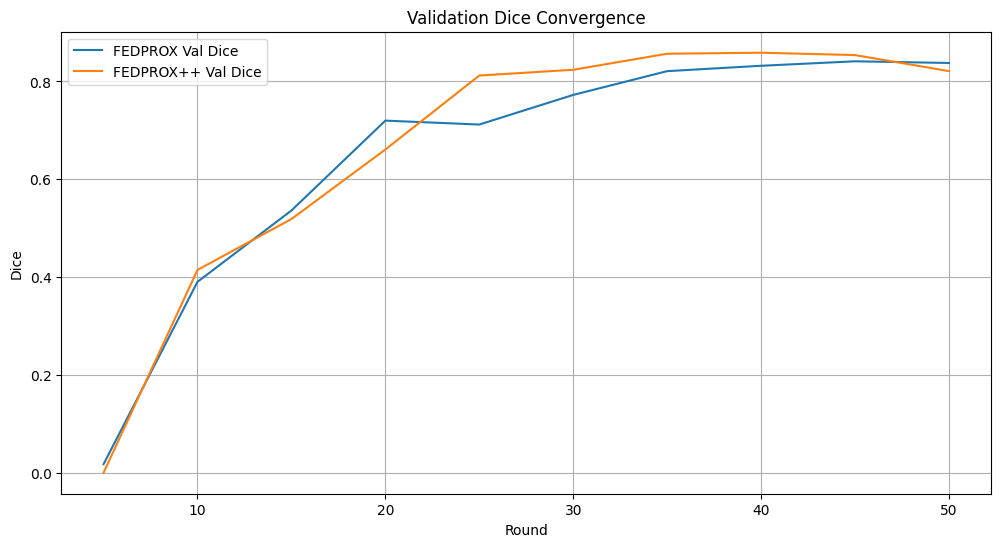

In [ ]:
plt.figure(figsize=(12, 6))
# FedAvg results (we need to collect them; if not stored, we can re-evaluate from logs)
# For simplicity, we assume comparison_results contains results for FedAvg?
# We did not store FedAvg results earlier; let's recompute quickly using the same evaluation on rounds.
# Instead, we'll plot only the algorithms for which we have results (fedprox, fedprox++, fedopt) and FedAvg baseline if available.
# We can re-run a quick evaluation of FedAvg's saved global_weights_fedavg at round intervals? We don't have per-round.
# To avoid recomputation, we'll plot only the three new algorithms plus maybe a placeholder for FedAvg?
# The user can also ignore this cell if not needed. We'll provide it for completeness using the results we already collected.
# In practice, you can extend train_federated_algorithm to also return per-round results for FedAvg.
# Here we only have results for the three new algorithms. We'll plot them.
for alg in ['fedprox', 'fedprox++']:
    res = comparison_results[alg]
    plt.plot(res['round'], res['val_dice'], label=f'{alg.upper()} Val Dice')
plt.xlabel('Round')
plt.ylabel('Dice')
plt.title('Validation Dice Convergence')
plt.legend()
plt.grid(True)
plt.show()

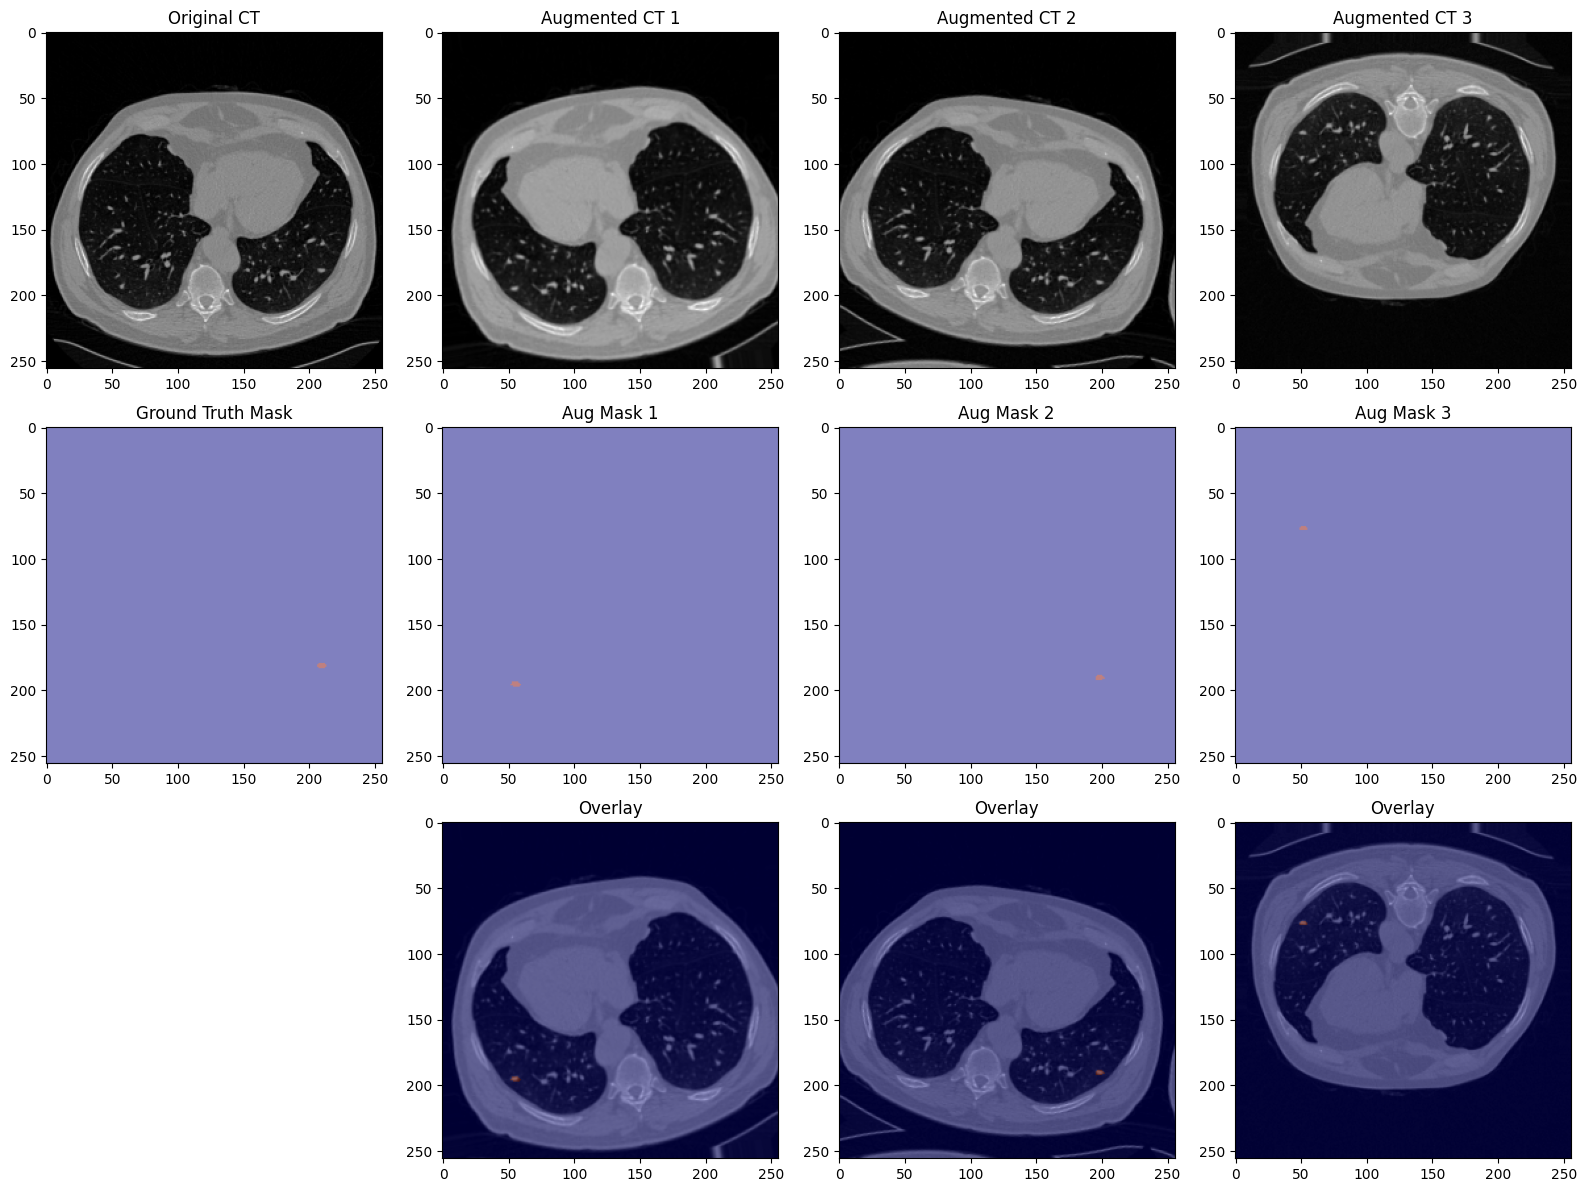

In [ ]:
sample_idx = random.randint(0, len(ct_paths)-1)
ct_img = cv2.imread(ct_paths[sample_idx], cv2.IMREAD_GRAYSCALE)
mask_img = cv2.imread(mask_paths[sample_idx], cv2.IMREAD_GRAYSCALE)

ct_resized = cv2.resize(ct_img, (256, 256)) / 255.0
mask_resized = (cv2.resize(mask_img, (256, 256), interpolation=cv2.INTER_NEAREST) > 127).astype(np.float32)

data_dict = {'image': np.expand_dims(ct_resized, 0), 'mask': np.expand_dims(mask_resized, 0)}

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes[0,0].imshow(ct_resized, cmap='gray')
axes[0,0].set_title('Original CT')
axes[1,0].imshow(mask_resized, cmap='jet', alpha=0.5)
axes[1,0].set_title('Ground Truth Mask')
axes[2,0].axis('off')

for i in range(1,4):
    augmented = train_transforms(data_dict.copy())
    aug_img = augmented['image'].squeeze().numpy()
    aug_mask = augmented['mask'].squeeze().numpy()
    axes[0,i].imshow(aug_img, cmap='gray')
    axes[0,i].set_title(f'Augmented CT {i}')
    axes[1,i].imshow(aug_mask, cmap='jet', alpha=0.5)
    axes[1,i].set_title(f'Aug Mask {i}')
    axes[2,i].imshow(aug_img, cmap='gray')
    axes[2,i].imshow(aug_mask, cmap='jet', alpha=0.4)
    axes[2,i].set_title('Overlay')

plt.tight_layout()
plt.show()

In [ ]:
def visualize_predictions_optimized(weights, dataloader, num_samples=5, threshold=0.5):
    model = build_model().to(device)
    model.load_state_dict(weights)
    model.eval()

    data_iter = iter(dataloader)
    imgs, masks = next(data_iter)
    imgs, masks = imgs.to(device), masks.to(device)

    with torch.no_grad():
        logits = model(imgs)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float().cpu().numpy()
        preds_pp = np.zeros_like(preds)
        for i in range(preds.shape[0]):
            preds_pp[i,0] = postprocess_mask_light(preds[i,0], min_area=2, fill_holes=True)
        preds = preds_pp

    imgs_np = imgs.cpu().numpy().squeeze(1)
    masks_np = masks.cpu().numpy().squeeze(1)
    preds_np = preds.squeeze(1)

    fig, axes = plt.subplots(num_samples, 4, figsize=(12, 3*num_samples))
    if num_samples == 1:
        axes = axes[None, :]

    for i in range(num_samples):
        ct = imgs_np[i]
        gt = masks_np[i]
        pred = preds_np[i]

        dice = compute_dice_from_pred(torch.tensor(pred).float().unsqueeze(0).unsqueeze(0),
                                      torch.tensor(gt).float().unsqueeze(0).unsqueeze(0)).item()

        axes[i,0].imshow(ct, cmap='gray')
        axes[i,0].set_title(f'CT Image {i+1}')
        axes[i,0].axis('off')

        axes[i,1].imshow(gt, cmap='jet', alpha=0.6)
        axes[i,1].set_title('Ground Truth')
        axes[i,1].axis('off')

        axes[i,2].imshow(pred, cmap='jet', alpha=0.6)
        axes[i,2].set_title(f'Prediction (Dice={dice:.3f})')
        axes[i,2].axis('off')

        axes[i,3].imshow(ct, cmap='gray')
        axes[i,3].imshow(pred, cmap='jet', alpha=0.4)
        axes[i,3].set_title('Overlay')
        axes[i,3].axis('off')

    plt.tight_layout()
    plt.show()

best_thresh_fedavg = find_best_threshold(global_weights_fedavg, client_dataloaders[0]['val'])
visualize_predictions_optimized(global_weights_fedavg, client_dataloaders[0]['test'], num_samples=5, threshold=best_thresh_fedavg)

In [ ]:
client_dices = []
client_ious = []
client_names = []

for i, client in enumerate(client_dataloaders):
    dice, iou = evaluate_with_optimizations(global_weights_fedavg, client['test'],
                                            threshold=best_thresh_fedavg, apply_postprocess=True)
    client_dices.append(dice)
    client_ious.append(iou)
    client_names.append(f'Client {i}')

x = np.arange(len(client_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10,5))
bar1 = ax.bar(x - width/2, client_dices, width, label='Dice', color='steelblue')
bar2 = ax.bar(x + width/2, client_ious, width, label='IoU', color='coral')

ax.set_ylabel('Score')
ax.set_title('Per‑Client Test Performance (FedAvg Baseline)')
ax.set_xticks(x)
ax.set_xticklabels(client_names)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bar1+bar2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0,3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
nodule_areas = []
for mask_path in mask_paths:
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = (mask > 127).astype(np.uint8)
    area = np.sum(mask)
    if area > 0:
        nodule_areas.append(area)

plt.figure(figsize=(8,5))
plt.hist(nodule_areas, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Nodule Area (pixels)')
plt.ylabel('Frequency')
plt.title('Distribution of Nodule Areas in Dataset')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
def overlay_contour(ct_img, pred_mask, gt_mask=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    ax.imshow(ct_img, cmap='gray')
    if gt_mask is not None:
        contours, _ = cv2.findContours(gt_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in contours:
            ax.plot(c[:,0,0], c[:,0,1], 'g-', linewidth=2, label='Ground Truth')
    if pred_mask is not None:
        contours, _ = cv2.findContours(pred_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in contours:
            ax.plot(c[:,0,0], c[:,0,1], 'r--', linewidth=2, label='Prediction')
    ax.legend()
    ax.axis('off')

example_idx = clients[0]['test'][0]
ct_ex = cv2.imread(ct_paths[example_idx], cv2.IMREAD_GRAYSCALE)
ct_ex = cv2.resize(ct_ex, (256,256)) / 255.0
gt_ex = (cv2.resize(cv2.imread(mask_paths[example_idx], cv2.IMREAD_GRAYSCALE), (256,256), interpolation=cv2.INTER_NEAREST) > 127).astype(np.float32)

model = build_model().to(device)
model.load_state_dict(global_weights_fedavg)
model.eval()
with torch.no_grad():
    input_tensor = torch.tensor(ct_ex[None,None,...], dtype=torch.float32).to(device)
    pred_prob = torch.sigmoid(model(input_tensor)).cpu().numpy().squeeze()
pred_mask = (pred_prob > best_thresh_fedavg).astype(np.float32)
pred_mask = postprocess_mask_light(pred_mask, min_area=2, fill_holes=True)

plt.figure(figsize=(6,6))
overlay_contour(ct_ex, pred_mask, gt_ex)
plt.title(f'Nodule Boundary: GT (green) vs Prediction (red), threshold={best_thresh_fedavg:.2f}')
plt.show()

In [ ]:
# Prepare per-client Dice data for all algorithms
algorithms = list(comparison_metrics.keys())
num_clients = 5
client_ids = range(num_clients)

# Extract Dice values
dice_data = {}
for alg in algorithms:
    dice_data[alg] = [comparison_metrics[alg]['client_metrics'][c]['dice'] for c in client_ids]

x = np.arange(num_clients)
width = 0.2  # width per bar

fig, ax = plt.subplots(figsize=(12, 6))
for i, alg in enumerate(algorithms):
    offset = (i - (len(algorithms)-1)/2) * width
    bars = ax.bar(x + offset, dice_data[alg], width, label=alg.upper())

ax.set_xlabel('Client')
ax.set_ylabel('Dice Score')
ax.set_title('Per‑Client Dice Comparison Across Federated Algorithms')
ax.set_xticks(x)
ax.set_xticklabels([f'Client {i}' for i in client_ids])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels for each bar
for i, alg in enumerate(algorithms):
    offset = (i - (len(algorithms)-1)/2) * width
    for j, val in enumerate(dice_data[alg]):
        ax.annotate(f'{val:.3f}', xy=(x[j] + offset, val), xytext=(0, 3),
                    textcoords="offset points", ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
# Extract mIoU values
miou_data = {}
for alg in algorithms:
    miou_data[alg] = [comparison_metrics[alg]['client_metrics'][c]['miou'] for c in client_ids]

fig, ax = plt.subplots(figsize=(12, 6))
for i, alg in enumerate(algorithms):
    offset = (i - (len(algorithms)-1)/2) * width
    bars = ax.bar(x + offset, miou_data[alg], width, label=alg.upper())

ax.set_xlabel('Client')
ax.set_ylabel('mIoU Score')
ax.set_title('Per‑Client mIoU Comparison Across Federated Algorithms')
ax.set_xticks(x)
ax.set_xticklabels([f'Client {i}' for i in client_ids])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

for i, alg in enumerate(algorithms):
    offset = (i - (len(algorithms)-1)/2) * width
    for j, val in enumerate(miou_data[alg]):
        ax.annotate(f'{val:.3f}', xy=(x[j] + offset, val), xytext=(0, 3),
                    textcoords="offset points", ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
import math

# Metrics to compare: Dice, Foreground IoU, mIoU, Precision, Recall
metrics_list = ['avg_dice', 'avg_iou', 'avg_miou', 'avg_precision', 'avg_recall']
metric_labels = ['Dice', 'Foreground IoU', 'mIoU', 'Precision', 'Recall']

# Number of variables
num_vars = len(metrics_list)

# Compute angle for each axis
angles = [n / float(num_vars) * 2 * math.pi for n in range(num_vars)]
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for alg in algorithms:
    values = [comparison_metrics[alg][m] for m in metrics_list]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=alg.upper())
    ax.fill(angles, values, alpha=0.1)

ax.set_theta_offset(math.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'])
ax.set_title('Average Metrics Radar Chart', size=16, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

In [ ]:
# Build a 2D array: rows = clients, columns = algorithms
dice_matrix = np.zeros((num_clients, len(algorithms)))
for j, alg in enumerate(algorithms):
    for i in range(num_clients):
        dice_matrix[i, j] = comparison_metrics[alg]['client_metrics'][i]['dice']

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(dice_matrix, cmap='viridis', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(np.arange(len(algorithms)))
ax.set_yticks(np.arange(num_clients))
ax.set_xticklabels([alg.upper() for alg in algorithms])
ax.set_yticklabels([f'Client {i}' for i in range(num_clients)])
ax.set_xlabel('Algorithm')
ax.set_ylabel('Client')
ax.set_title('Dice Score Heatmap per Client and Algorithm')

# Add colorbar
plt.colorbar(im, ax=ax)

# Annotate each cell with the numeric value
for i in range(num_clients):
    for j in range(len(algorithms)):
        text = ax.text(j, i, f'{dice_matrix[i, j]:.3f}',
                       ha="center", va="center", color="w", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Extract average Dice and mIoU for each algorithm
summary = []
for alg in comparison_metrics.keys():
    summary.append({
        'Algorithm': alg.upper(),
        'Average Dice': comparison_metrics[alg]['avg_dice'],
        'Average mIoU': comparison_metrics[alg]['avg_miou']
    })

# Create DataFrame and display
df_summary = pd.DataFrame(summary)
print("Dice and mIoU Comparison Table:")
print(df_summary.to_string(index=False))

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df_summary.values,
                 colLabels=df_summary.columns,
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.title("Federated Algorithm Performance Comparison")
plt.show()